In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_olivetti_faces
faces_data = fetch_olivetti_faces(shuffle = True)
X = faces_data.data
print(X.shape)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
(400, 4096)


In [2]:
W, H = faces_data.images.shape[2], faces_data.images.shape[1]
print(W, H)

64 64


In [3]:
pca = PCA(n_components = 300)
pca.fit(X)

PCA(n_components=300)

In [4]:
cara_original = X[0:1]

cara_comprimida = pca.transform(cara_original)

In [6]:
def recontruir_con_k_componentes(k):
  cara_reducida = cara_comprimida[:, :k]
  if k < 300:
    padding = np.zeros((1, 300 -k))
    cara_reducida = np.concatenate((cara_reducida, padding), axis = 1)
  cara_k_recontruida = pca.inverse_transform(cara_reducida)
  return cara_k_recontruida.reshape(H,W)


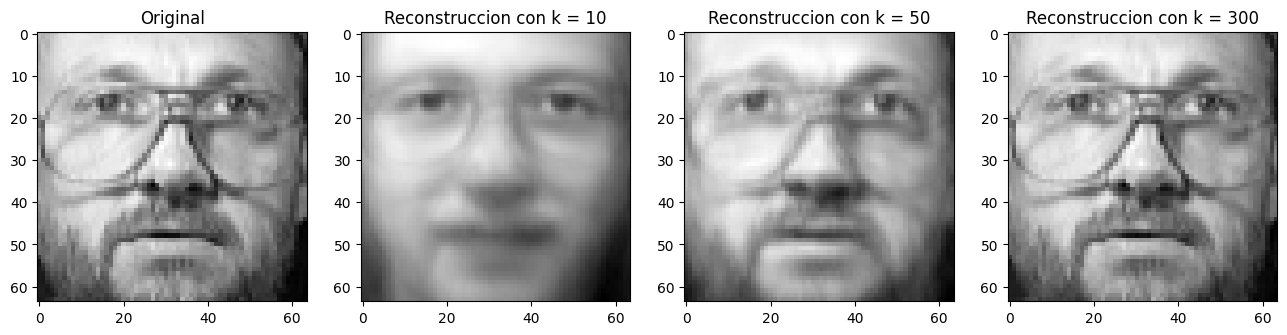

In [7]:
fig, axes = plt.subplots(1,4, figsize=(16,5))
axes[0].imshow(cara_original.reshape(H,W), cmap = 'gray')
axes[0].set_title('Original')

axes[1].imshow(recontruir_con_k_componentes(k=10), cmap = 'gray')
axes[1].set_title('Reconstruccion con k = 10')

axes[2].imshow(recontruir_con_k_componentes(k=50), cmap = 'gray')
axes[2].set_title('Reconstruccion con k = 50')

axes[3].imshow(recontruir_con_k_componentes(k=300), cmap = 'gray')
axes[3].set_title('Reconstruccion con k = 300')

plt.show()

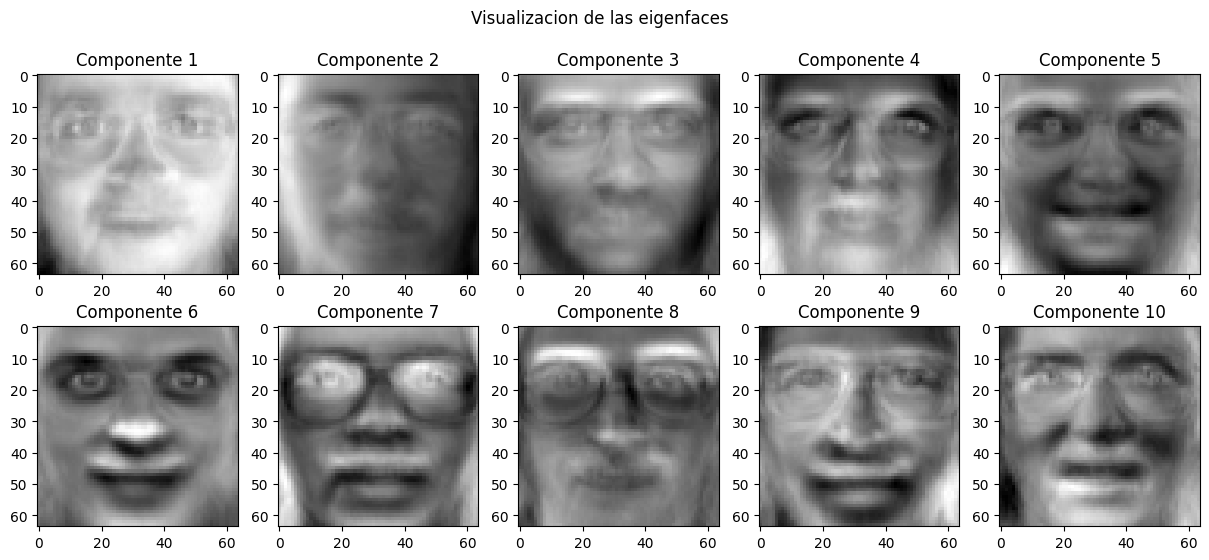

In [8]:
fig, axes = plt.subplots(2,5, figsize =(15,6))
for i, ax in enumerate(axes.flat): # convertir matriz de ejes en una lista
  ax.imshow(pca.components_[i].reshape(H,W), cmap = 'gray')
  ax.set_title(f'Componente {i+1}')

plt.suptitle('Visualizacion de las eigenfaces')
plt.show()
